In [3]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
from sklearn.cluster import KMeans
import pandas as pd

In [100]:
def calc_MSE(img_original, img_rec):
    altura, largura = img_original.shape[0], img_original.shape[1]

    dif = img_original.astype(np.float64) - img_rec.astype(np.float64)

    mse_total = np.sum(dif**2, axis=(0, 1)) / (altura * largura * 3)

    return np.sum(mse_total)


def calc_PSNR(mse, max=255.0):
    if mse == 0:
        return "VAI DAR ERRADO"

    return 10 * np.log10((max ** 2) / mse)    
 
def calc_CR(altura, largura, k):
    tam_original = altura * largura * 3 * 8

    bits_por_idx = np.ceil(np.log2(k))
    tam_comp = altura * largura * bits_por_idx + k * 8 * 3

    return tam_original/tam_comp
    




In [94]:
img_og = cv.imread('bloomiz.png')
img_og = cv.cvtColor(img_og, cv.COLOR_BGR2RGB).astype(np.uint8)

img_og_float = img_og.astype(np.float32) / 255.0 

img_cie = cv.cvtColor(img_og_float, cv.COLOR_RGB2LAB)

img_arr = img_cie.reshape(-1, 3)

In [103]:
kmeans = KMeans(n_clusters=16, random_state=42)
kmeans.fit(img_arr)

centroides = kmeans.cluster_centers_
labels = kmeans.labels_

novos_centroides = centroides.reshape(1, -1, 3)

paleta_float = cv.cvtColor(novos_centroides, cv.COLOR_LAB2RGB)

paletaaa_float = np.round(paleta_float.reshape(-1, 3)*255)

cores_int = np.clip(paletaaa_float, 0, 255).astype(np.uint8)

In [104]:
altura, largura = img_og.shape[0], img_og.shape[1]

labels_2d = labels.reshape(altura, largura)

In [105]:
from PIL import Image

img_indexada = Image.fromarray(labels_2d.astype(np.uint8), mode='P')
paleta_achatada = cores_int.flatten().tolist()
paleta_achatada += [0] * (768 - len(paleta_achatada))

img_indexada.putpalette(paleta_achatada)

img_indexada.save('teste16.png')

[]

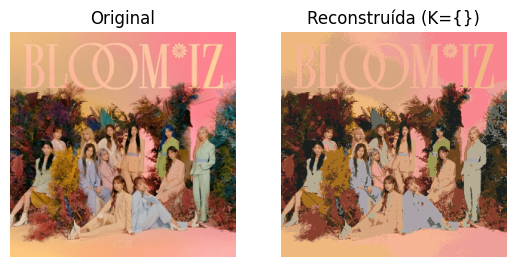

In [98]:
img_reconstruida = np.zeros((altura, largura, 3), dtype=np.uint8)
# # img_reconstruida2 = img_og

# # saida2 = cv.cvtColor(img_reconstruida2, cv.COLOR_RGB2BGR)
# # cv.imwrite('teste.png', saida2)



for i in range(altura):
    for j in range(largura):
        idx_cluster = labels_2d[i][j]
        img_reconstruida[i][j] = cores_int[idx_cluster]

# plt.imshow(img_reconstruida)
# plt.axis('off')
# plt.savefig('bloomizrec.png', bbox_inches='tight', pad_inches=0, transparent=True)

# plt.imsave('teste3.png', img_reconstruida)

# img_final = Image.fromarray(img_reconstruida)
# img_final.save('teste_kmeans2.png', format='PNG')
# saida = cv.cvtColor(img_reconstruida, cv.COLOR_RGB2BGR)

# cv.imwrite('bloomizrec.png', saida)

plt.subplot(1, 2, 1)
plt.imshow(img_og)
plt.title('Original')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(img_reconstruida)
plt.title("Reconstruída (K={})")
plt.axis('off')
plt.plot()

In [102]:
mse = calc_MSE(img_og, img_reconstruida)
psnr = calc_PSNR(mse)
psnr2 = cv.PSNR(img_og, img_reconstruida)
cr = calc_CR(altura, largura, 16)

print(mse)
print(psnr)
print(psnr2)
print(cr)

198.68597037037037
25.149131591121243
25.149131591121243
5.993606819392648


In [14]:
# k_clusters = [2, 4, 8, 16, 32, 64, 128, 256]

# for k in k_clusters:
#     kmeans = KMeans(n_clusters=k, random_state=42)
#     kmeans.fit(img_arr)

#     centroides = kmeans.cluster_centers_
#     labels = kmeans.labels_

#     novos_centroides = centroides.reshape(1, -1, 3)

#     paleta_float = cv.cvtColor(novos_centroides, cv.COLOR_LAB2RGB)

#     paletaaa_float = np.round(paleta_float.reshape(-1, 3)*255)

#     cores_int = np.clip(paletaaa_float, 0, 255).astype(np.uint8)

#     altura, largura = img_og.shape[0], img_og.shape[1]

#     labels_2d = labels.reshape(altura, largura)

#     img_reconstruida = np.zeros((altura, largura, 3), dtype=np.uint8)

#     for i in range(altura):
#         for j in range(largura):
#             idx_cluster = labels_2d[i][j]
#             img_reconstruida[i][j] = cores_int[idx_cluster]

#     mse = calc_MSE(img_og, img_reconstruida)
#     psnr = calc_PSNR(mse)
#     cr = calc_CR(altura, largura, k)

#     dff = {
#         "K": k,
#         "mse": mse,
#         "PSNR": psnr,
#         "CR": cr,
#     }

#     df = pd.DataFrame(dff)